# AirBnB NYC Analytics Project 

* Project by Nhi Bui · Villanova University · [GitHub](https://github.com/nhibui23/airbnb-saas-product-analytics) · [LinkedIn](https://linkedin.com/in/nhiuyenbui)

**Goal:** What listing features drive higher engagement
on Airbnb?

**Success Metrics:**

- number of reviews (primary)
- reviews per month (secondary)
- review rate number (secondary)

**Business Questions:**

**Q1. What host listing factors controlled by hosts most significantly impact review ratings?**

Investigate whether `minimum nights`, `host_identity_verified`, and `availability 365` have a statistically significant effect on `review rate number`

→ Recommend minimum listing quality requirements to sort out  underperforming hosts.

**Q2. Does enabling Instant Book lead to higher review engagement?**

Test whether listings with `instant_bookable = True` generate significantly more `number of reviews` and higher `reviews_per_month` compared to non-instant-bookable listings. 

→ Recommend Airbnb prioritize prompting hosts to enable Instant Book as a growth lever.

**Q3. Which neighbourhoods show the highest listing quality and booking activity?**

Identify areas with the highest `review_rate_number` and `reviews_per_month` to push high-performing markets. 

→ Recommend Airbnb concentrate host acquisition and marketing efforts in these locations to maximize platform growth.

## 1. Load the data
Loading the Airbnb NYC Data from Kaggle 

In [2]:
pip -q install ipykernel pandas numpy matplotlib seaborn statsmodels scipy


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

## 2. Understand the data
Import data from uploaded Airbnb_Open_Data.csv abd read the data overview to check its quality and format

In [4]:
#Read data type and total number of entries & columns
df = pd.read_csv('../data/Airbnb_Open_Data.csv', low_memory=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  str    
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  str    
 4   host name                       102193 non-null  str    
 5   neighbourhood group             102570 non-null  str    
 6   neighbourhood                   102583 non-null  str    
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  str    
 10  country code                    102468 non-null  str    
 11  instant_bookable                102494 non-null  object 
 12  cancellation_policy        

In [5]:
#Understand data statistics summary
df.describe()

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [6]:
#Acknowledge the top 5 AirBnB listings in the dataset
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [7]:
#List out all column names in the dataset
df.columns.tolist()

['id',
 'NAME',
 'host id',
 'host_identity_verified',
 'host name',
 'neighbourhood group',
 'neighbourhood',
 'lat',
 'long',
 'country',
 'country code',
 'instant_bookable',
 'cancellation_policy',
 'room type',
 'Construction year',
 'price',
 'service fee',
 'minimum nights',
 'number of reviews',
 'last review',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'house_rules',
 'license']

## 3. Data Cleaning - Data Type

Our first step is to clean data and prepare data to ensure data quality before Exploratory Data Analysis

## A. Data Cleaning - Data Type

Our first step is to clean data and prepare data to ensure data quality before Exploratory Data Analysis
* Step 1: Change data type of service fee and price

In [8]:
#Change data type of service fee from string to float, removing $ sign 
df['service fee'] = df['service fee'].str.replace('$', '').astype(float)

In [9]:
#Change data type of price from string to float, removing $ sign and comma
df['price'] = df['price'].str.replace(r'[\$,]', '', regex=True).astype(float)

In [10]:
#Change data type of review rate number from string to float, removing $ sign and comma
df['review rate number'] = df['review rate number'].astype(float)


* Step 2: Check data of instant_bookable as objects to see what values are in it

In [11]:
#Check instant_bookable column data type and unique values
df['instant_bookable'].value_counts()


instant_bookable
False    51474
True     51020
Name: count, dtype: int64

* Step 3: Convert last review to date time

In [12]:
#Convert last review date to datetime format
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

* Step 4: Recode for neighborhood group

In [13]:
#Check all values of neighbourhood group
df['neighbourhood group'].value_counts()

neighbourhood group
Manhattan        43792
Brooklyn         41842
Queens           13267
Bronx             2712
Staten Island      955
brookln              1
manhatan             1
Name: count, dtype: int64

In [14]:
#Recode the neighbourhood group variable from "brookln" to "Brooklyn"
df['neighbourhood group'] = df['neighbourhood group'].replace('brookln', 'Brooklyn')

## B. Clean data - Data Missing Values
* Step 1: Check for missing values and count total missing values from each column in descending order

In [15]:
#Check for missing values in the dataset
df.isnull().sum().sort_values(ascending=False)

license                           102597
house_rules                        52131
last review                        15893
reviews per month                  15879
country                              532
availability 365                     448
minimum nights                       409
host name                            406
review rate number                   326
calculated host listings count       319
host_identity_verified               289
service fee                          273
NAME                                 250
price                                247
Construction year                    214
number of reviews                    183
country code                         131
instant_bookable                     105
cancellation_policy                   76
neighbourhood group                   29
neighbourhood                         16
long                                   8
lat                                    8
id                                     0
host id         

In [16]:
#Delete redundant columns and columns with higher tha 50% missing values that are not needed for the dataset
df.drop(columns=['license', 'country', 'country code', 'host name', 'house_rules'], inplace=True)

In [17]:
#Check the missing values of other columns
df.isnull().sum().sort_values(ascending=False)

last review                       15893
reviews per month                 15879
availability 365                    448
minimum nights                      409
review rate number                  326
calculated host listings count      319
host_identity_verified              289
service fee                         273
NAME                                250
price                               247
Construction year                   214
number of reviews                   183
instant_bookable                    105
cancellation_policy                  76
neighbourhood group                  29
neighbourhood                        16
lat                                   8
long                                  8
id                                    0
host id                               0
room type                             0
dtype: int64

* Step 2: Handle "Last Review" column

Listings with no "last review" date are inactive, as they've never been booked or reviewed, so they carry no engagement signal and were removed. Therefore, this filters the dataset down to listings that actually generate value.

In [18]:
#Check the top listings with higher missing values for last review than number of reviews
df[df['last review'].isnull()]['number of reviews'].value_counts().head(10).sort_values(ascending=False)


number of reviews
0.0      15734
11.0         2
8.0          2
191.0        1
25.0         1
70.0         1
24.0         1
12.0         1
84.0         1
10.0         1
Name: count, dtype: int64

In [19]:
#Check the top listings with higher missing values for last review than reviews per month
df[df['last review'].isnull()]['reviews per month'].value_counts(). head(10).sort_values(ascending = False)

reviews per month
1.65    1
0.22    1
0.62    1
0.28    1
0.87    1
0.13    1
0.77    1
0.03    1
0.10    1
0.04    1
Name: count, dtype: int64

*Clean analytical reasoning*

* 15,734 have 0 reviews → genuinely inactive listings → drop them
* A small handful have reviews but no date 
→ This can signal a data collection error rather than a pattern 
→ We can also drop them 
→ Listings with all null `last review` were excluded as they represent inactive or never-booked listings with no engagement signal.

In [20]:
#Drop rows with missing values for last review 
df.dropna(subset=['last review'], inplace=True)

In [21]:
#Check the dataset for missing values again
df.isnull().sum().sort_values(ascending=False)

minimum nights                    345
review rate number                288
calculated host listings count    261
host_identity_verified            247
service fee                       241
price                             221
NAME                              214
Construction year                 185
availability 365                  180
instant_bookable                   93
cancellation_policy                67
number of reviews                  59
neighbourhood group                25
neighbourhood                      16
reviews per month                  13
lat                                 7
long                                7
host id                             0
id                                  0
room type                           0
last review                         0
dtype: int64

* Step 3: Handle "Number of reviews" & "Review rate number" columns

These are our important success metric columns, so we need to take a careful analysis before deciding whether to drop missing value rows, conduct imputation or informative missing


We need to see if those missing value rows have a last review date or reviews per month values, which will tell whether they genuinely have reviews but the count is just missing, or if they're truly zero-review listings that slipped through.

In [22]:
#Check numer of reviews column for missing values and its other columns if they have values
df[df['number of reviews'].isnull()][['last review', 'reviews per month', 'review rate number']].head(20)

,last review,reviews per month,review rate number
97,2019-07-07,0.71,NaN
566,2019-07-01,0.65,3.0
1066,2018-09-30,0.64,5.0
1591,2018-09-18,0.43,5.0
2141,2019-06-21,3.68,1.0
3149,2019-07-02,3.49,3.0
4840,2019-04-05,0.26,3.0
6627,2019-03-28,1.06,3.0
7104,2015-03-05,0.09,1.0
7606,2018-01-02,0.25,3.0


In [23]:
#Check number of review rate number for missing values and its other columns if they have values
df[df['review rate number'].isnull()][['last review', 'reviews per month', 'number of reviews']].head(20)

,last review,reviews per month,number of reviews
28,2017-08-13,0.49,58.0
29,2019-06-15,1.11,108.0
30,2019-04-19,0.24,29.0
31,2019-06-01,2.04,242.0
32,2019-06-14,1.42,88.0
33,2019-06-15,1.65,197.0
34,2019-07-01,2.37,273.0
35,2019-05-12,0.66,74.0
36,2019-06-21,1.41,168.0
45,2019-06-13,0.84,97.0


Because these missing-value rows are not by mistake, we now conduct correlation testing to see the correlation between values and decide whether we are capable of conducting imputation.

In [24]:
#Define numerical columns
numerical_cols = ['price', 'service fee', 'minimum nights', 'number of reviews', 
                  'reviews per month', 'review rate number', 'calculated host listings count', 
                  'availability 365', 'Construction year']


#Check for correlation of number of reviews columns with other related column
df[numerical_cols].corr()

,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,Construction year
price,1.000000,0.999991,-0.004658,0.004618,0.004200,-0.006573,0.000538,-0.000342,-0.003691
service fee,0.999991,1.000000,-0.004940,0.004571,0.004106,-0.006409,0.000691,-0.000735,-0.003385
minimum nights,-0.004658,-0.004940,1.000000,-0.046497,-0.096140,0.001101,0.068729,0.044509,0.001594
number of reviews,0.004618,0.004571,-0.046497,1.000000,0.591084,-0.020443,-0.080057,0.107917,0.002256
reviews per month,0.004200,0.004106,-0.096140,0.591084,1.000000,0.037606,-0.025638,0.077306,0.004084
review rate number,-0.006573,-0.006409,0.001101,-0.020443,0.037606,1.000000,0.023865,-0.011838,0.005250
calculated host listings count,0.000538,0.000691,0.068729,-0.080057,-0.025638,0.023865,1.000000,0.134415,-0.003427
availability 365,-0.000342,-0.000735,0.044509,0.107917,0.077306,-0.011838,0.134415,1.000000,-0.007659
Construction year,-0.003691,-0.003385,0.001594,0.002256,0.004084,0.005250,-0.003427,-0.007659,1.000000


<Axes: >

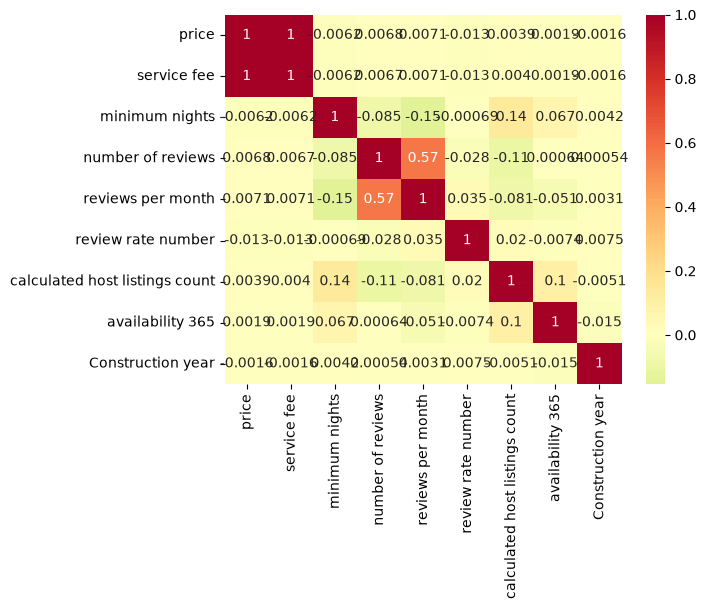

In [38]:
#Create heatmap to visualize the correlation of number of reviews columns with other related column
import seaborn as sns

sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='RdYlGn_r', center=0)


None of the engagement metrics correlate strongly with listing characteristics like price or availability, meaning success on Airbnb isn't predictable from a single feature, as it depends on combinations that warrant deeper statistical testing

In [26]:
#Drop rows with missing values for number of reviews
df.dropna(subset=['number of reviews'], inplace=True)

In [27]:
#Drop rows with missing values for review rate number
df.dropna(subset=['review rate number'], inplace=True)

* Step 4: Handle other missing-values columns

We decide to drop all other rows with missing values due to its small handful of missing values compared to the number of data points in the dataset

In [28]:
#Drop rows with missing values
df.dropna(inplace=True)

* Step 5: Check for missing values again

In [29]:
#Check for missing values in the dataset again
df.isnull().sum().sort_values(ascending=False)


id                                0
NAME                              0
host id                           0
host_identity_verified            0
neighbourhood group               0
neighbourhood                     0
lat                               0
long                              0
instant_bookable                  0
cancellation_policy               0
room type                         0
Construction year                 0
price                             0
service fee                       0
minimum nights                    0
number of reviews                 0
last review                       0
reviews per month                 0
review rate number                0
calculated host listings count    0
availability 365                  0
dtype: int64

## C. Clean data - Data Outliers

Check for outliers in potential columns

In [30]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,8.462100e+04,8.462100e+04,84621.000000,84621.000000,84621.000000,84621.000000,84621.000000,84621.000000,84621.000000,84621,84621.000000,84621.000000,84621.000000,84621.000000
mean,2.958890e+07,4.917913e+10,40.727366,-73.948512,2012.489217,626.025077,125.206107,7.428853,32.177864,2019-06-11 19:31:47.654128,1.374158,3.280155,7.030725,141.776509
min,1.001254e+06,1.236005e+08,40.504560,-74.249840,2003.000000,50.000000,10.000000,-365.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,1.548596e+07,2.444852e+10,40.687660,-73.982130,2007.000000,340.000000,68.000000,2.000000,3.000000,2018-10-27 00:00:00,0.220000,2.000000,1.000000,6.000000
50%,3.081560e+07,4.902423e+10,40.721350,-73.953720,2012.000000,625.000000,125.000000,3.000000,11.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,101.000000
75%,4.328653e+07,7.384633e+10,40.762640,-73.930850,2017.000000,914.000000,183.000000,5.000000,38.000000,2019-07-05 00:00:00,2.000000,4.000000,2.000000,266.000000
max,5.736024e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.620052e+07,2.852984e+10,0.056345,0.050372,5.761291,331.687120,66.341067,27.944748,51.786965,NaN,1.746965,1.282509,29.426592,133.924340


From this, we decide to check for outliers in columns: price, minimum nights, availability 365 and calculated host listings count

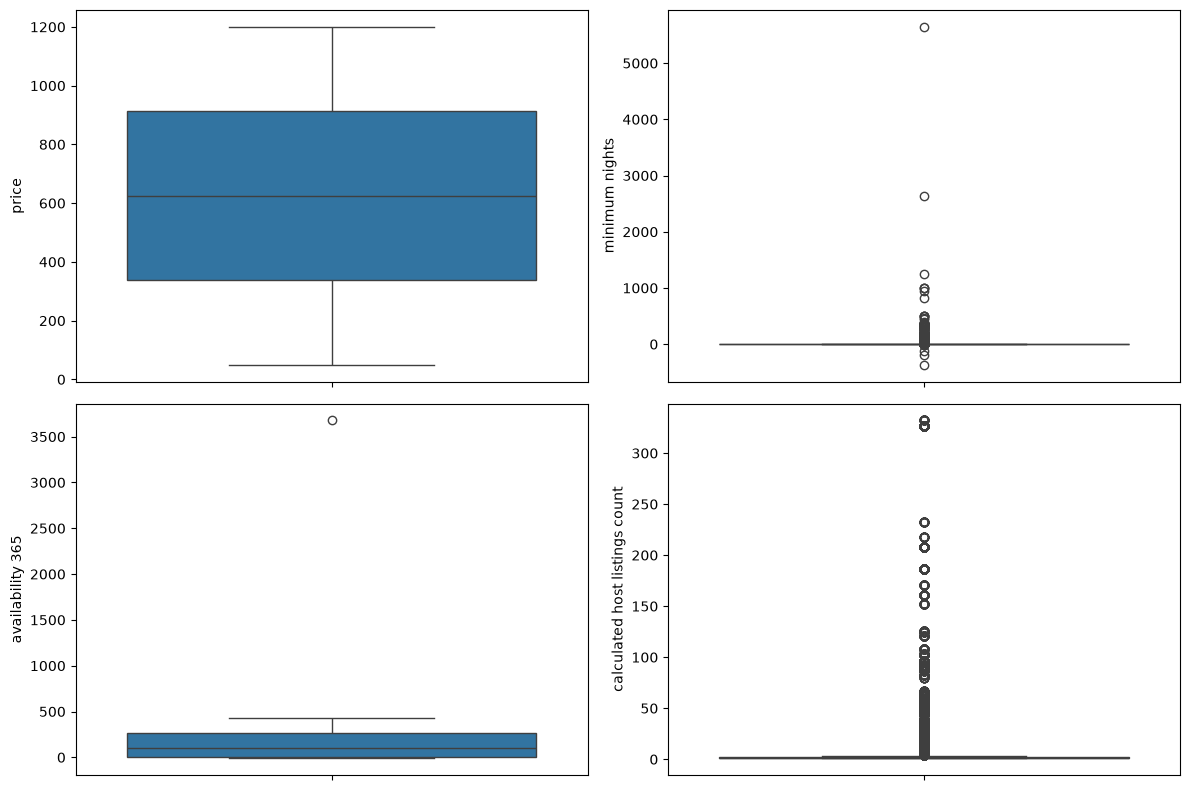

In [31]:
#Plot the distribution for these features
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, y='price', ax=axes[0,0])
sns.boxplot(data=df, y='minimum nights', ax=axes[0,1])
sns.boxplot(data=df, y='availability 365', ax=axes[1,0])
sns.boxplot(data=df, y='calculated host listings count', ax=axes[1,1])

plt.tight_layout()
plt.show()


By looking at the chart, we make 4 conclusions
* Price: The range from 50-1200 is reasonable, especially for high-cost areas like NYC
* Availability 365: we will set an upper limit of 365 (relative to 365 days a year) and 0 days available for every house listing
* Minimum nights: based on the chart, we will remove outliers below 0 and above 3000
* Calculated host listing count: based on the graph, we will remove outliers above 300 listings

In [32]:
#Filter for availability 365
df= df[(df['availability 365'] <= 365) & (df['availability 365'] > 0)]

In [33]:
#Filter for minimum nights
df = df[(df['minimum nights'] > 0) & (df['minimum nights'] < 3000)]


In [34]:
#Filter for calculated host listings count
df = df[df['calculated host listings count'] < 300]

In [35]:
#Check for statistical summary of the dataset after filtering
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,6.371800e+04,6.371800e+04,63718.000000,63718.000000,63718.000000,63718.000000,63718.000000,63718.000000,63718.000000,63718,63718.000000,63718.000000,63718.000000,63718.000000
mean,2.895498e+07,4.908258e+10,40.726881,-73.946103,2012.516400,626.569855,125.314275,7.749427,37.322656,2019-09-17 16:20:49.304749,1.614967,3.290546,6.651778,173.066088
min,1.001254e+06,1.297566e+08,40.504560,-74.249840,2003.000000,50.000000,10.000000,1.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,1.000000
25%,1.544522e+07,2.439515e+10,40.686380,-73.982047,2008.000000,341.000000,68.000000,1.000000,4.000000,2019-04-27 00:00:00,0.320000,2.000000,1.000000,63.000000
50%,3.023540e+07,4.877215e+10,40.721520,-73.952740,2013.000000,625.000000,125.000000,3.000000,15.000000,2019-06-23 00:00:00,1.000000,3.000000,1.000000,162.000000
75%,4.175321e+07,7.369808e+10,40.762760,-73.927680,2018.000000,914.000000,183.000000,5.000000,48.000000,2020-03-19 18:00:00,2.400000,4.000000,3.000000,287.000000
max,5.736024e+07,9.876268e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,2645.000000,1024.000000,2022-05-21 00:00:00,90.000000,5.000000,232.000000,365.000000
std,1.595758e+07,2.850600e+10,0.057772,0.053623,5.772182,331.354481,66.273160,21.647479,55.474306,NaN,1.869026,1.278247,22.458412,120.332458


In [36]:
#Check the shape of the dataset after filtering
df.info()

<class 'pandas.DataFrame'>
Index: 63718 entries, 0 to 102593
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              63718 non-null  int64         
 1   NAME                            63718 non-null  str           
 2   host id                         63718 non-null  int64         
 3   host_identity_verified          63718 non-null  str           
 4   neighbourhood group             63718 non-null  str           
 5   neighbourhood                   63718 non-null  str           
 6   lat                             63718 non-null  float64       
 7   long                            63718 non-null  float64       
 8   instant_bookable                63718 non-null  object        
 9   cancellation_policy             63718 non-null  str           
 10  room type                       63718 non-null  str           
 11  Construction year

## Takeaway 

Cleaning reduced the dataset from 102,599 to 63,718 active, valid listings, which is a 38% drop. This is the cost of working with messy real-world data, but the remaining listings represent market activity and form a foundation for statistical testing.

In [37]:
#Save excel as a cleaned dataset for future use
df.to_csv('../data/Airbnb_Open_Data_Cleaned.csv', index=False)

## Summary

This notebook produces a clean dataset of around 64000 active NYC Airbnb listings ready for analysis. Inactive listings, data entry errors, and outliers have been removed while keeping the range of NYC pricing and stay patterns.

After data preparation and cleaning, we will start to conduct Exploratory Data Analysis, ANOVA Testing, A/B Testing and location statsistical analysis to answer our 3 business questions